## Проект: Выбор локации для скважины

### Цель проекта:
- Поиск перспективной локации для бурения скважины. 

### План проекта:
- Загрузить и подготовить данные.
- Обучить и проверить модель для каждого региона.
- Расчет прибыли и рисков.
- Вывод.

### Описание данных:
Данные геологоразведки трёх регионов находятся в файлах: 
- /datasets/geo_data_0.csv.
- /datasets/geo_data_1.csv.
- /datasets/geo_data_2.csv.  
  - id — уникальный идентификатор скважины;
  - f0, f1, f2 — три признака точек (неважно, что они означают, но сами признаки значимы);
  - product — объём запасов в скважине (тыс. баррелей).

### Условия задачи:
- Для обучения модели подходит только линейная регрессия (остальные — недостаточно предсказуемые).
- При разведке региона исследуют 500 точек, из которых с помощью машинного обучения выбирают 200 лучших для разработки.
- Бюджет на разработку скважин в регионе — 10 млрд рублей.
- При нынешних ценах один баррель сырья приносит 450 рублей дохода. Доход с каждой единицы продукта составляет 450 тыс. рублей, поскольку объём указан в тысячах баррелей.
- После оценки рисков нужно оставить лишь те регионы, в которых вероятность убытков меньше 2.5%. Среди них выбирают регион с наибольшей средней прибылью.

## 1. Загрузка и подготовка данных

In [11]:
# загружаем библиотеки

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

In [12]:
# загружаем датафреймы, выводим их и их размерность

geo_0 = pd.read_csv('geo_data_0.csv')
geo_1 = pd.read_csv('geo_data_1.csv')
geo_2 = pd.read_csv('geo_data_2.csv')

display(geo_0.head(), geo_0.shape)
display(geo_1.head(), geo_1.shape)
display(geo_2.head(), geo_2.shape)

,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647


(100000, 5)

,id,f0,f1,f2,product
0,kBEdx,-15.001348,-8.276000,-0.005876,3.179103
1,62mP7,14.272088,-3.475083,0.999183,26.953261
2,vyE1P,6.263187,-5.948386,5.001160,134.766305
3,KcrkZ,-13.081196,-11.506057,4.999415,137.945408
4,AHL4O,12.702195,-8.147433,5.004363,134.766305


(100000, 5)

,id,f0,f1,f2,product
0,fwXo0,-1.146987,0.963328,-0.828965,27.758673
1,WJtFt,0.262778,0.269839,-2.530187,56.069697
2,ovLUW,0.194587,0.289035,-5.586433,62.871910
3,q6cA6,2.236060,-0.553760,0.930038,114.572842
4,WPMUX,-0.515993,1.716266,5.899011,149.600746


(100000, 5)

In [13]:
# посмотрим пропуски, дубликаты и тип данных

regions = [geo_0, geo_1, geo_2]
region_names = ['Регион 0', 'Регион 1', 'Регион 2']

for i, df in enumerate(regions):
    print(f'\n{region_names[i]}:')
    print('Пропуски:')
    print(df.isnull().sum())
    print('-' * 3)
    print('Дубликаты :')
    print(df.duplicated().sum())
    print('-' * 3)
    print('Типы данных :')
    print(df.dtypes)
    print('-' * 30)


Регион 0:
Пропуски:
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64
---
Дубликаты :
0
---
Типы данных :
id             str
f0         float64
f1         float64
f2         float64
product    float64
dtype: object
------------------------------

Регион 1:
Пропуски:
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64
---
Дубликаты :
0
---
Типы данных :
id             str
f0         float64
f1         float64
f2         float64
product    float64
dtype: object
------------------------------

Регион 2:
Пропуски:
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64
---
Дубликаты :
0
---
Типы данных :
id             str
f0         float64
f1         float64
f2         float64
product    float64
dtype: object
------------------------------


Данные в порядке. Корректировки не требуются.

Регион 0:


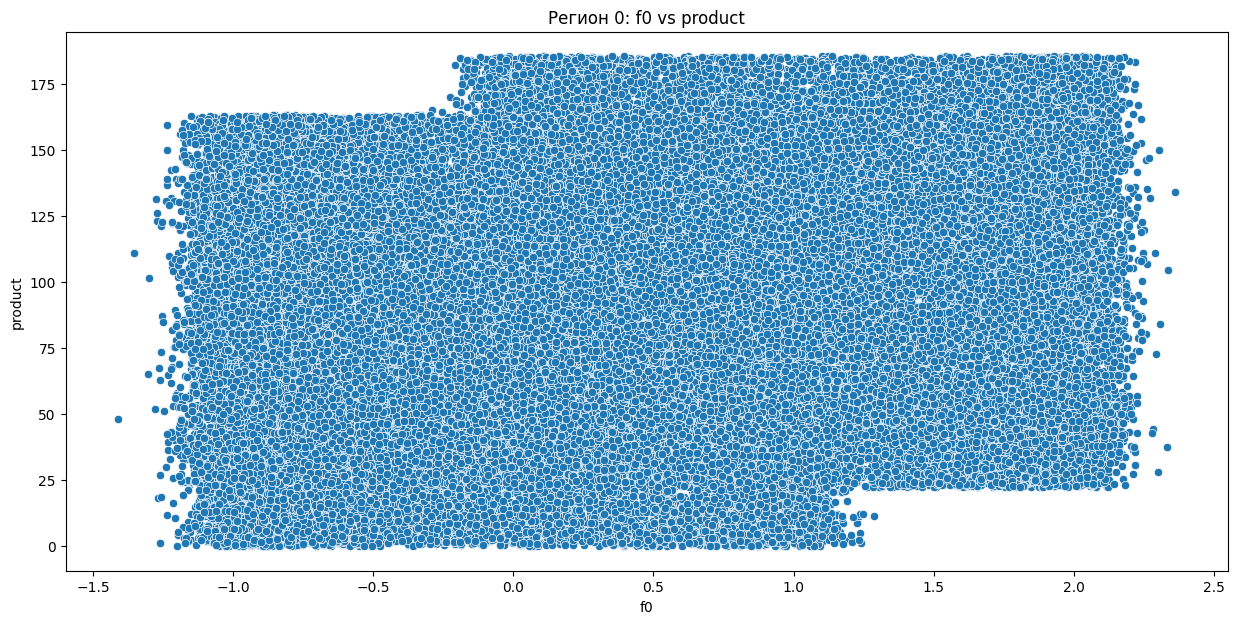

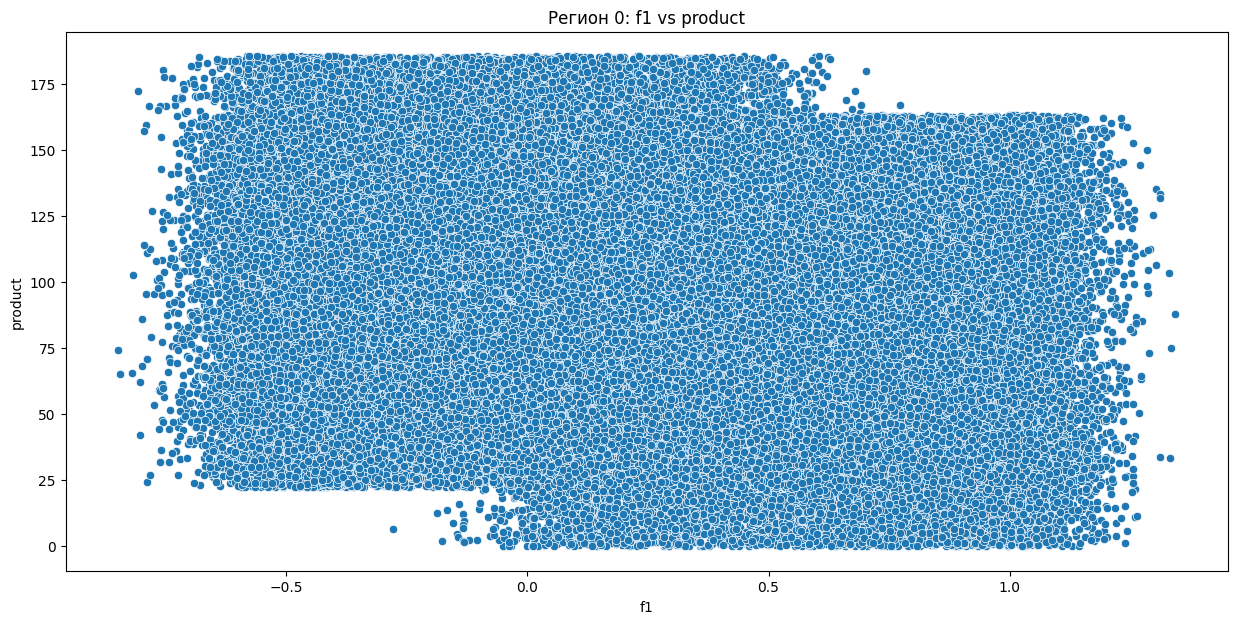

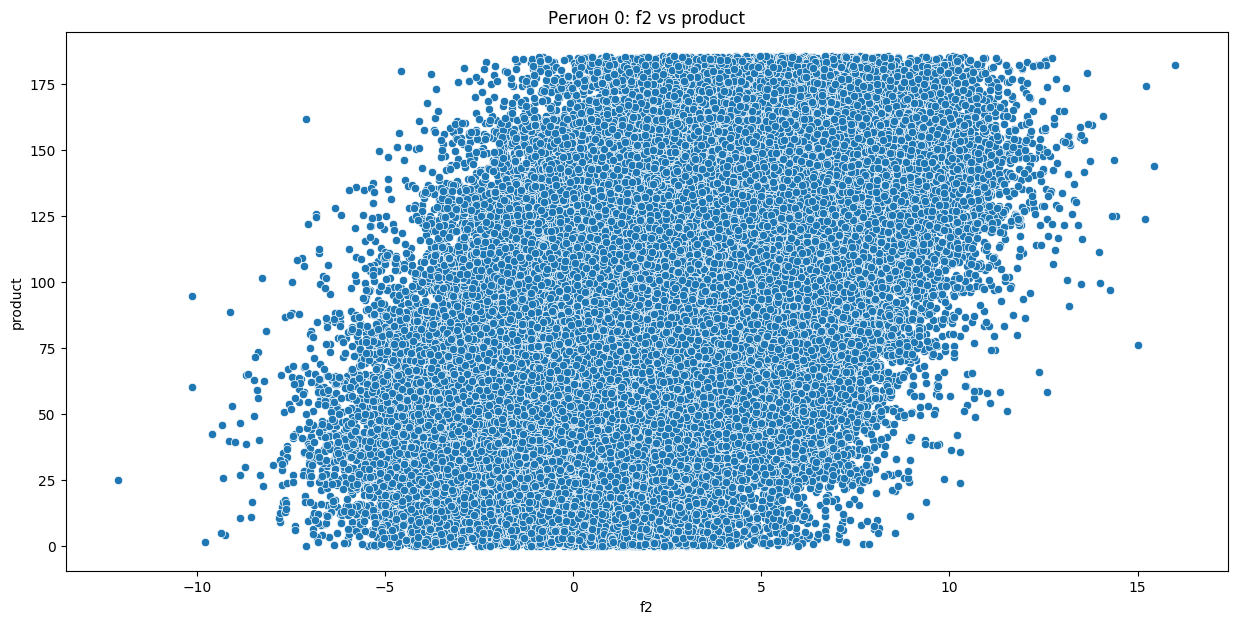

Регион 1:


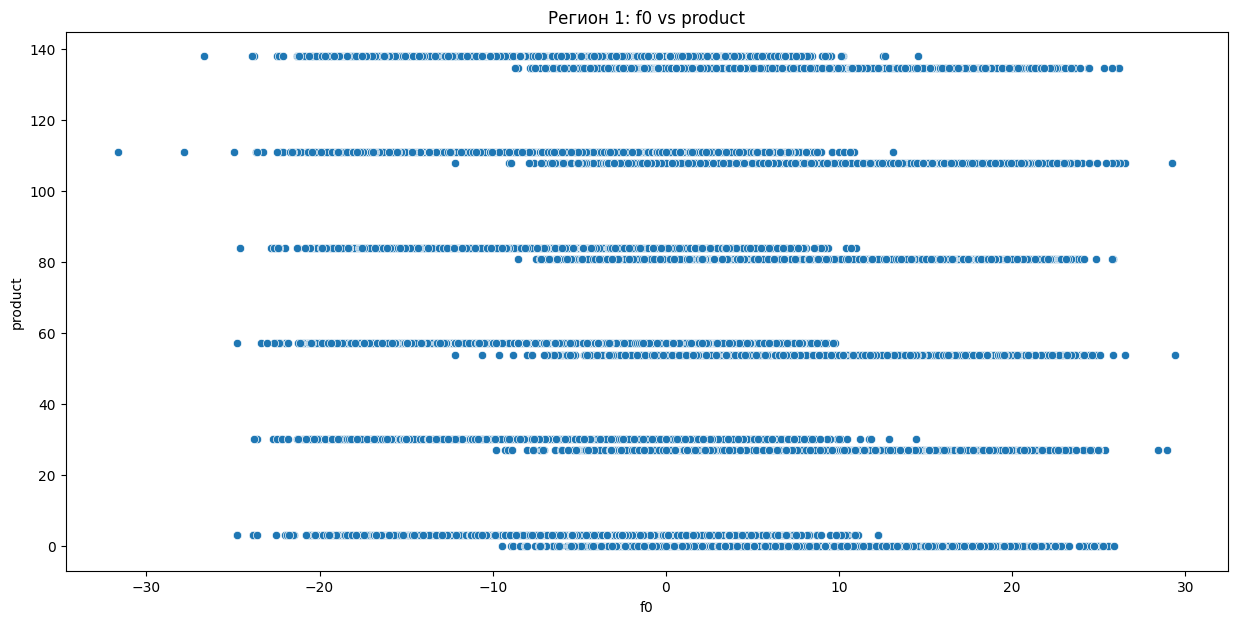

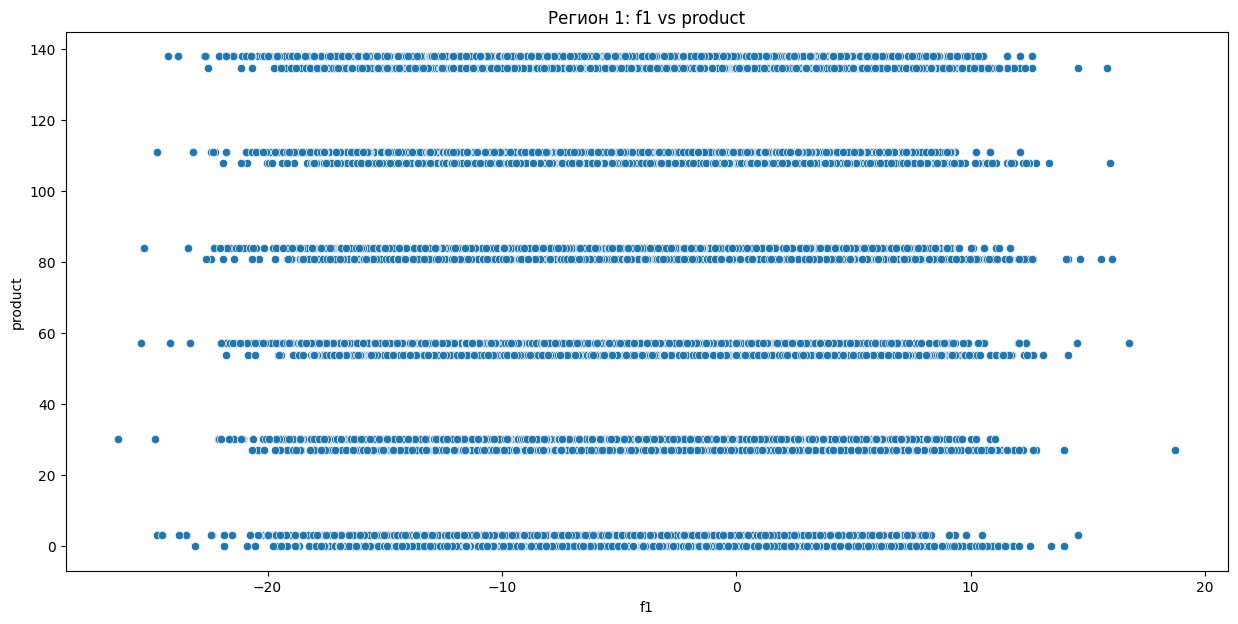

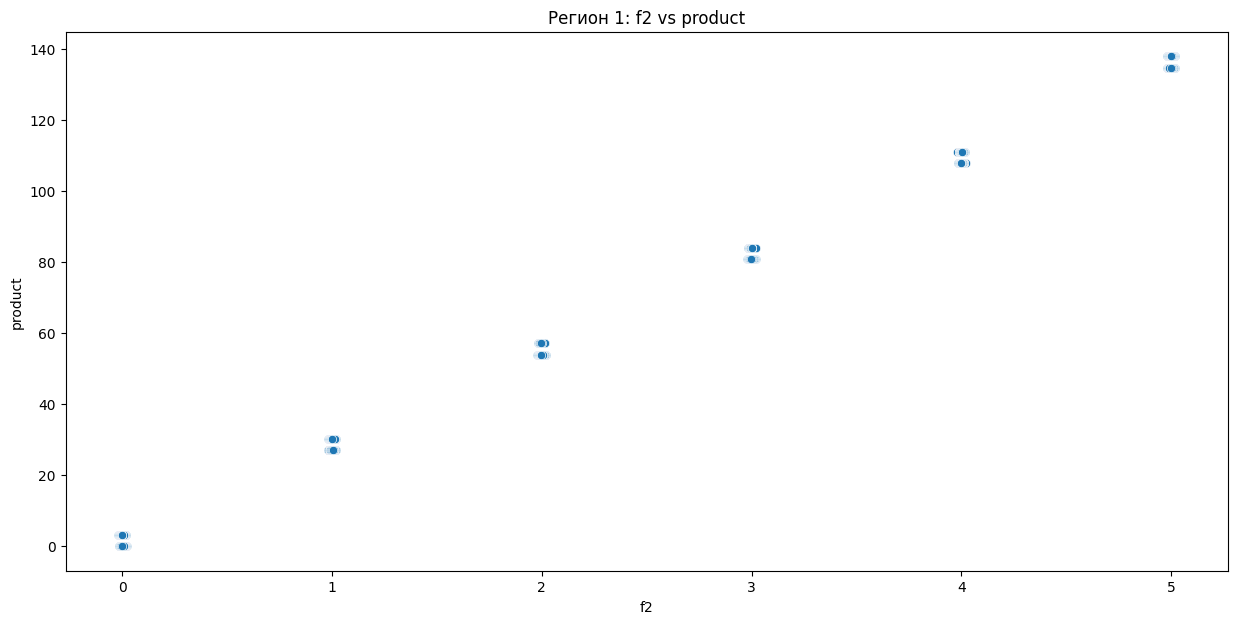

Регион 2:


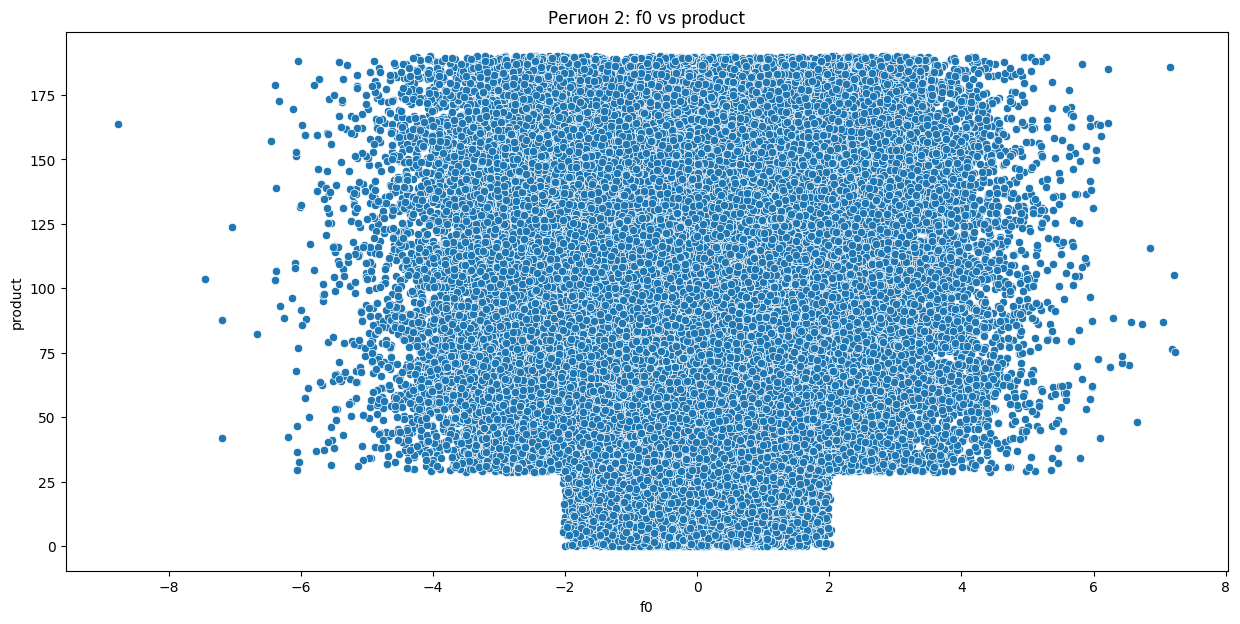

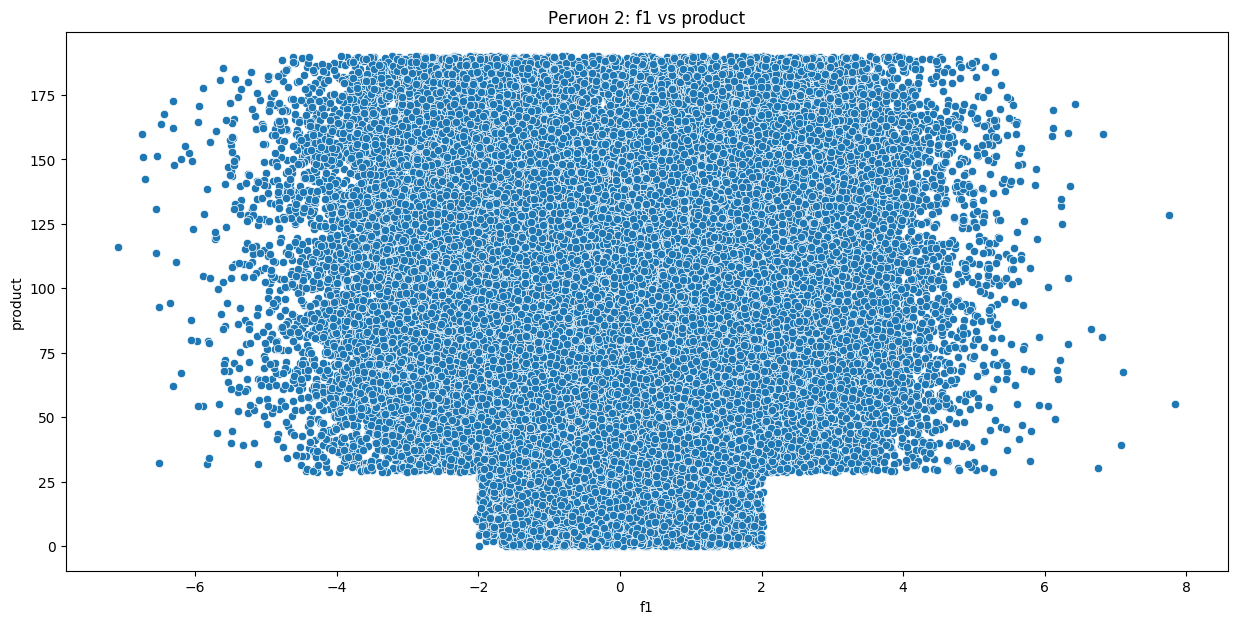

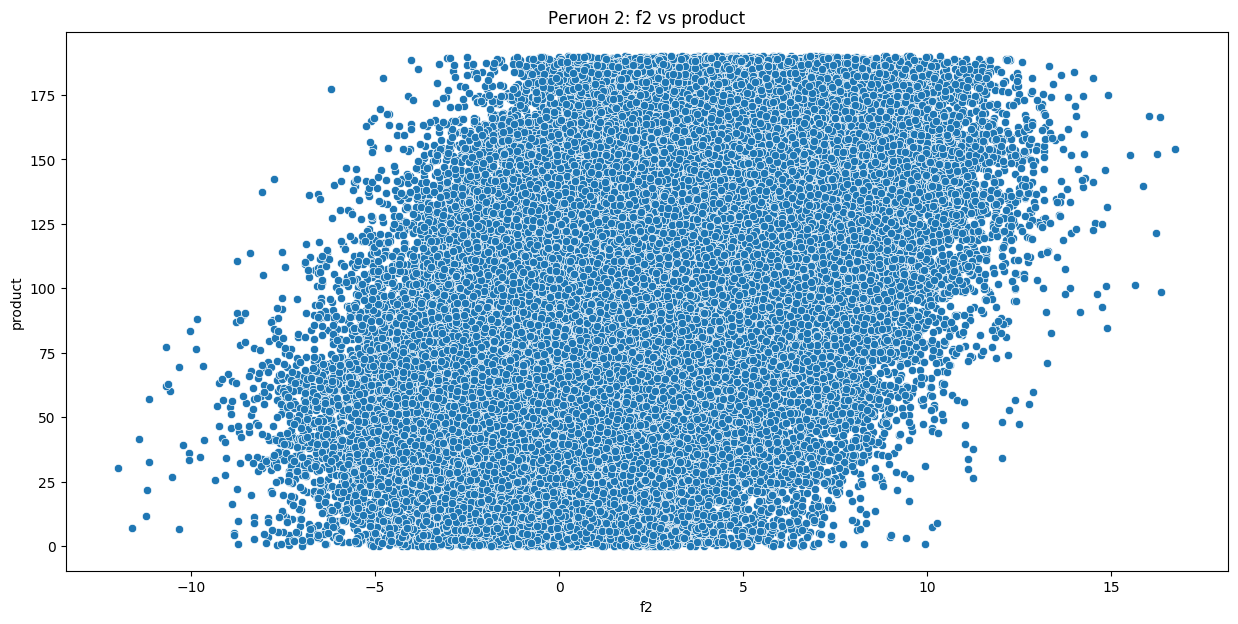

In [14]:
# посмотрим распределение и корреляции


for j, df in enumerate(regions):
    num_cols = df.select_dtypes(include = 'number').columns
    print(f"Регион {j}:")
    
    for i in num_cols:
        if i != 'product':
            plt.figure(figsize = (15, 7))
            sns.scatterplot(
                data = df,
                x = i,
                y = 'product'
            )
            plt.title(f"Регион {j}: {i} vs product")
            plt.show()

Видим различное распределение.

In [15]:
# проведем статистический анализ
display(geo_0.describe())
display(geo_1.describe())
display(geo_2.describe())

,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.500419,0.250143,2.502647,92.500000
std,0.871832,0.504433,3.248248,44.288691
min,-1.408605,-0.848218,-12.088328,0.000000
25%,-0.072580,-0.200881,0.287748,56.497507
50%,0.502360,0.250252,2.515969,91.849972
75%,1.073581,0.700646,4.715088,128.564089
max,2.362331,1.343769,16.003790,185.364347


,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.141296,-4.796579,2.494541,68.825000
std,8.965932,5.119872,1.703572,45.944423
min,-31.609576,-26.358598,-0.018144,0.000000
25%,-6.298551,-8.267985,1.000021,26.953261
50%,1.153055,-4.813172,2.011479,57.085625
75%,8.621015,-1.332816,3.999904,107.813044
max,29.421755,18.734063,5.019721,137.945408


,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.002023,-0.002081,2.495128,95.000000
std,1.732045,1.730417,3.473445,44.749921
min,-8.760004,-7.084020,-11.970335,0.000000
25%,-1.162288,-1.174820,0.130359,59.450441
50%,0.009424,-0.009482,2.484236,94.925613
75%,1.158535,1.163678,4.858794,130.595027
max,7.238262,7.844801,16.739402,190.029838


Данные хорошие, выбросы не наблюдаются.

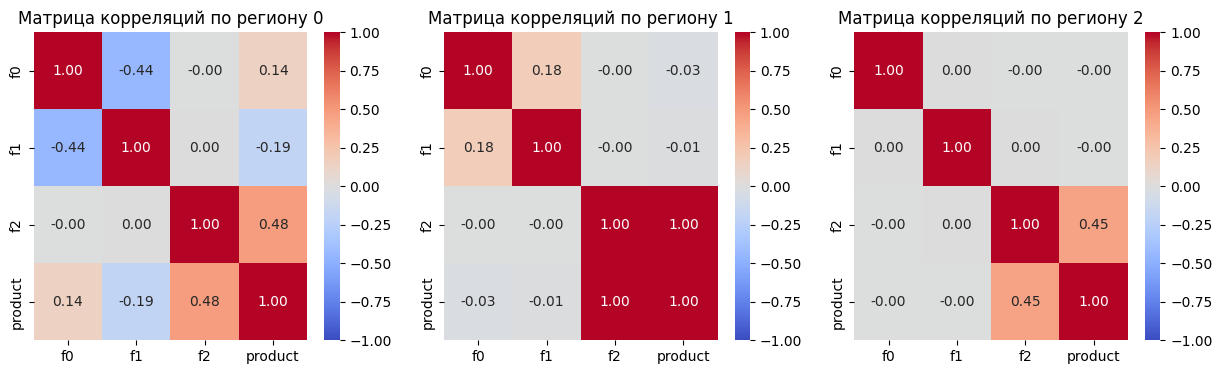

In [16]:
# посмотрим корреляцию

corr_matrix_0 = geo_0.drop(columns=['id']).corr()
corr_matrix_1 = geo_1.drop(columns=['id']).corr()
corr_matrix_2 = geo_2.drop(columns=['id']).corr()

plt.figure(figsize = (15, 4))

plt.subplot(1, 3, 1)
sns.heatmap(
    corr_matrix_0,
    annot = True,
    fmt = ".2f",
    vmin = -1,
    vmax = 1,
    cmap = 'coolwarm'
)
plt.title('Матрица корреляций по региону 0')

plt.subplot(1, 3, 2)
sns.heatmap(
    corr_matrix_1,
    annot = True,
    fmt = ".2f",
    vmin = -1,
    vmax = 1,
    cmap = 'coolwarm'
)
plt.title('Матрица корреляций по региону 1')

plt.subplot(1, 3, 3)
sns.heatmap(
    corr_matrix_2,
    annot = True,
    fmt = ".2f",
    vmin = -1,
    vmax = 1,
    cmap = 'coolwarm'
)
plt.title('Матрица корреляций по региону 2');

По всем трем регионам видим сильную корреляцию между f2 и product.

## 2. Обучение и проверка модели

In [17]:
# сделаем модель для региона 0

X_zero = geo_0.drop(columns = ['product', 'id'])
y_zero = geo_0['product']

X_train_zero, X_test_zero, y_train_zero, y_test_zero = train_test_split(
    X_zero, y_zero,
    test_size = 0.25,
    random_state = 42
)

model_zero = LinearRegression()
model_zero.fit(X_train_zero, y_train_zero)

y_pred_train_zero = model_zero.predict(X_train_zero)
y_pred_test_zero = model_zero.predict(X_test_zero)

print('Модель 0')
print('Веса признаков:', model_zero.coef_)
print('Свободный член:', model_zero.intercept_)
print('MAE train:', mean_absolute_error(y_train_zero, y_pred_train_zero))
print('MAE test:', mean_absolute_error(y_test_zero, y_pred_test_zero))
print('RMSE test:', np.sqrt(mean_squared_error(y_test_zero, y_pred_test_zero)))
print('R2 test:', r2_score(y_test_zero, y_pred_test_zero))
print('Средний запас нефти в тестовой выборке:', y_test_zero.mean())

Модель 0
Веса признаков: [  3.83225372 -14.26047297   6.59357294]
Свободный член: 77.66624978042196
MAE train: 31.03666880056252
MAE test: 31.047681538788183
RMSE test: 37.756600350261685
R2 test: 0.2728287328173473
Средний запас нефти в тестовой выборке: 92.32595637084387


**Качество модели регоина 0:**

R² = 0.27 - объясняет 27% изменчивости данных  
Ошибка предсказания: ±31 тыс. баррелей (MAE)  
Средний запас: 92 тыс. баррелей  
Относительная ошибка:  
31 / 92 ≈ 34% - модель ошибается на ±34% от среднего значения

In [18]:
# сделаем модель для региона 1

X_one = geo_1.drop(columns = ['product', 'id'])
y_one = geo_1['product']

X_train_one, X_test_one, y_train_one, y_test_one = train_test_split(
    X_one, y_one,
    test_size = 0.25,
    random_state = 42
)

model_one = LinearRegression()
model_one.fit(X_train_one, y_train_one)

y_pred_train_one = model_one.predict(X_train_one)
y_pred_test_one = model_one.predict(X_test_one)

print('Модель 1')
print('Веса признаков:', model_one.coef_)
print('Свободный член:', model_one.intercept_)
print('MAE train:', mean_absolute_error(y_train_one, y_pred_train_one))
print('MAE test:', mean_absolute_error(y_test_one, y_pred_test_one))
print('RMSE test:', np.sqrt(mean_squared_error(y_test_one, y_pred_test_one)))
print('R2 test:', r2_score(y_test_one, y_pred_test_one))
print('Средний запас нефти в тестовой выборке:', y_test_one.mean())

Модель 1
Веса признаков: [-1.44912960e-01 -2.16715104e-02  2.69531092e+01]
Свободный член: 1.6476710499669451
MAE train: 0.717485030544889
MAE test: 0.7170119535682573
RMSE test: 0.8902801001028863
R2 test: 0.9996245232002449
Средний запас нефти в тестовой выборке: 68.72538074722743


**Качество модели региона 1:**

R² = 1 - объясняет 100% изменчивости данных  
Ошибка предсказания: 0.72 тыс. баррелей (MAE)  
Средний запас: 69 тыс. баррелей  

In [19]:
# сделаем модель для региона 2

X_two = geo_2.drop(columns = ['product', 'id'])
y_two = geo_2['product']

X_train_two, X_test_two, y_train_two, y_test_two = train_test_split(
    X_two, y_two,
    test_size = 0.25,
    random_state = 42
)

model_two = LinearRegression()
model_two.fit(X_train_two, y_train_two)

y_pred_train_two = model_two.predict(X_train_two)
y_pred_test_two = model_two.predict(X_test_two)

print('Модель 2')
print('Веса признаков:', model_two.coef_)
print('Свободный член:', model_two.intercept_)
print('MAE train:', mean_absolute_error(y_train_two, y_pred_train_two))
print('MAE test:', mean_absolute_error(y_test_two, y_pred_test_two))
print('RMSE test:', np.sqrt(mean_squared_error(y_test_two, y_pred_test_two)))
print('R2 test:', r2_score(y_test_two, y_pred_test_two))
print('Средний запас нефти в тестовой выборке:', y_test_two.mean())

Модель 2
Веса признаков: [-0.08415777 -0.01546094  5.75011968]
Свободный член: 80.55786205197192
MAE train: 32.79271624193568
MAE test: 32.896958610578054
RMSE test: 40.14587231134218
R2 test: 0.19634705977280464
Средний запас нефти в тестовой выборке: 95.15099907171961


**Качество модели региона 2:**

R² = 0.2 - объясняет 20% изменчивости данных  
Ошибка предсказания: 33 тыс. баррелей (MAE)  
Средний запас: 95 тыс. баррелей  

In [20]:
# сравнение моделей

results = []
for i, (model, region_name) in enumerate(zip([model_zero, model_one, model_two], ['Регион 0', 'Регион 1', 'Регион 2'])):
    results.append({
        'Регион': region_name,
        'R²': r2_score([y_test_zero, y_test_one, y_test_two][i], 
                      [y_pred_test_zero, y_pred_test_one, y_pred_test_two][i]),
        'MAE': mean_absolute_error([y_test_zero, y_test_one, y_test_two][i],
                                 [y_pred_test_zero, y_pred_test_one, y_pred_test_two][i]),
        'RMSE': np.sqrt(mean_squared_error([y_test_zero, y_test_one, y_test_two][i], [y_pred_test_zero, y_pred_test_one, y_pred_test_two][i])),
        'Средний запас': [y_test_zero.mean(), y_test_one.mean(), y_test_two.mean()][i]
    })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

  Регион       R²       MAE      RMSE  Средний запас
Регион 0 0.272829 31.047682 37.756600      92.325956
Регион 1 0.999625  0.717012  0.890280      68.725381
Регион 2 0.196347 32.896959 40.145872      95.150999


Регион 1: Идеальная модель (R² = 1.0)
   - Объясняет 100% дисперсии данных
   - Минимальная ошибка предсказания
   - Возможно, синтетические данные

Регион 0: Хорошая модель (R² = 0.27)
   - Объясняет 27% дисперсии данных
   - Ошибка предсказания: ±31 тыс. баррелей

Регион 2: Слабая модель (R² = 0.20)
   - Объясняет только 20% дисперсии данных
   - Наибольшая ошибка предсказания

## 3. Подготовка к расчёту прибыли

In [21]:
# добавим ключевые значения для расчетов

budget = 10000000000
one_barrel = 450
oil_well = 200

In [22]:
# посчитаем достаточный объем сырья, для безубыточной разработки

good_volume = budget / one_barrel
print(f'Необходимый объем для безубыточности: {good_volume:.2f} баррелей')
print(f'Необходимый объем для безубыточности на 1 скважину: {good_volume / oil_well :.2f} баррелей')

Необходимый объем для безубыточности: 22222222.22 баррелей
Необходимый объем для безубыточности на 1 скважину: 111111.11 баррелей


In [23]:
# средние объемы по регионам

print('Средний объем по 0 региону:', (geo_0['product'].mean() * 1000).round(2))
print('Средний объем по 1 региону:', (geo_1['product'].mean() * 1000).round(2))
print('Средний объем по 2 региону:', (geo_2['product'].mean() * 1000).round(2))

Средний объем по 0 региону: 92500.0
Средний объем по 1 региону: 68825.0
Средний объем по 2 региону: 95000.0


**Вывод:**

Для безубыточности необходимо добыть 22.3 млн баррелей. Средний запас одной скважины составляет около 90 тыс. баррелей, поэтому для достижения безубыточности требуется отбор скважин с запасами выше среднего.

## 4. Расчёт прибыли и рисков 

In [24]:
# сделаем функцию для расчета прибыли

def calculate_profit(target, predictions, count):
    # Выбираем индексы скважин с самыми высокими предсказаниями
    top_indices = np.argsort(predictions)[-count:]
    
    # Суммируем фактические запасы этих скважин
    total_volume = target.iloc[top_indices].sum()
    
    # Рассчитываем прибыль
    profit = total_volume * 450000 - 10000000000
    
    return profit

In [25]:
# проверка по регионам

profit_0 = calculate_profit(y_test_zero, y_pred_test_zero, oil_well)
print(f"Прибыль региона 0: {profit_0:,.0f} руб.")

profit_1 = calculate_profit(y_test_one, y_pred_test_one, oil_well)
print(f"Прибыль региона 1: {profit_1:,.0f} руб.")

profit_2 = calculate_profit(y_test_two, y_pred_test_two, oil_well)
print(f"Прибыль региона 2: {profit_2:,.0f} руб.")

Прибыль региона 0: 3,359,141,114 руб.
Прибыль региона 1: 2,415,086,697 руб.
Прибыль региона 2: 2,598,571,759 руб.


Результаты:

Регион 0: 3.36 млрд руб. прибыли  
Регион 2: 2.60 млрд руб. прибыли  
Регион 1: 2.42 млрд руб. прибыли

In [26]:
# функция для bootstrap

def bootstrap_profit(target, predictions, n_bootstrap=1000):
    profits = []
    n_samples = 500
    
    for _ in range(n_bootstrap):
        indices = np.random.randint(0, len(target), n_samples)
        target_sample = target.iloc[indices]
        pred_sample = predictions[indices]
        
        profit = calculate_profit(target_sample, pred_sample, 200)
        profits.append(profit)
    
    return np.array(profits)

# проводим анализ для всех регионов
bootstrap_results = {}
for i, (target, pred) in enumerate(zip(
    [y_test_zero, y_test_one, y_test_two],
    [y_pred_test_zero, y_pred_test_one, y_pred_test_two]
)):
    profits = bootstrap_profit(target, pred)
    bootstrap_results[f'Регион {i}'] = profits
    print(f'Регион {i}: завершено')

# анализируем результаты
for region, profits in bootstrap_results.items():
    print(f'\n{region}:')
    print(f'Средняя прибыль: {profits.mean()/1e9:.2f} млрд руб.')
    print(f'95% интервал: [{np.percentile(profits, 2.5)/1e9:.2f}, {np.percentile(profits, 97.5)/1e9:.2f}] млрд руб.')
    print(f'Вероятность убытков: {(profits < 0).mean():.2%}')

Регион 0: завершено
Регион 1: завершено
Регион 2: завершено

Регион 0:
Средняя прибыль: 0.40 млрд руб.
95% интервал: [-0.09, 0.93] млрд руб.
Вероятность убытков: 5.20%

Регион 1:
Средняя прибыль: 0.44 млрд руб.
95% интервал: [0.03, 0.83] млрд руб.
Вероятность убытков: 1.90%

Регион 2:
Средняя прибыль: 0.39 млрд руб.
95% интервал: [-0.15, 0.93] млрд руб.
Вероятность убытков: 8.80%


## Итоги bootstrap-анализа

| Регион | Средняя прибыль | 95% интервал | Вероятность убытков |
|:---|---:|---:|---:|
| 0 | 0.40 млрд | [-0.09, 0.93] млрд | 5.20% |
| **1** | **0.44 млрд** | **[0.03, 0.83] млрд** | **1.90%** |
| 2 | 0.39 млрд | [-0.15, 0.93] млрд | 8.80% |

**Выбран Регион 1** — единственный с риском убытков ниже 2.5% (1.90%) и максимальной средней прибылью (0.44 млрд руб.).

Регионы 0 и 2 исключены — риск убытков превышает порог 2.5%.